Dataset shape: (500, 6)
       danceability   energy    tempo  loudness  valence
count       500.000  500.000  500.000   500.000  500.000
mean          0.583    0.550  102.129    -9.632    0.536
std           0.214    0.254   24.471     7.278    0.188
min           0.000    0.000   40.000   -31.409    0.000
25%           0.424    0.299   83.864   -14.385    0.398
50%           0.646    0.619  102.312    -6.730    0.551
75%           0.751    0.748  122.225    -4.267    0.677
max           0.972    1.000  153.147     0.000    1.000

✓ Features normalized (MinMaxScaler)

✓ Optimal K by silhouette = 5  (score=0.5222)
✓ KMeans converged in 13 iterations
  Inertia         : 29.18
  Silhouette      : 0.3176
  Davies-Bouldin  : 1.2442

Cluster sizes:
cluster
0     48
1     96
2     96
3    215
4     45
Name: count, dtype: int64

✓ Model and Scaler saved to disk.

✓ PCA variance explained: 81.6%
✓ t-SNE projection complete

✓ Saved → /content/spotify_clustering_report.png


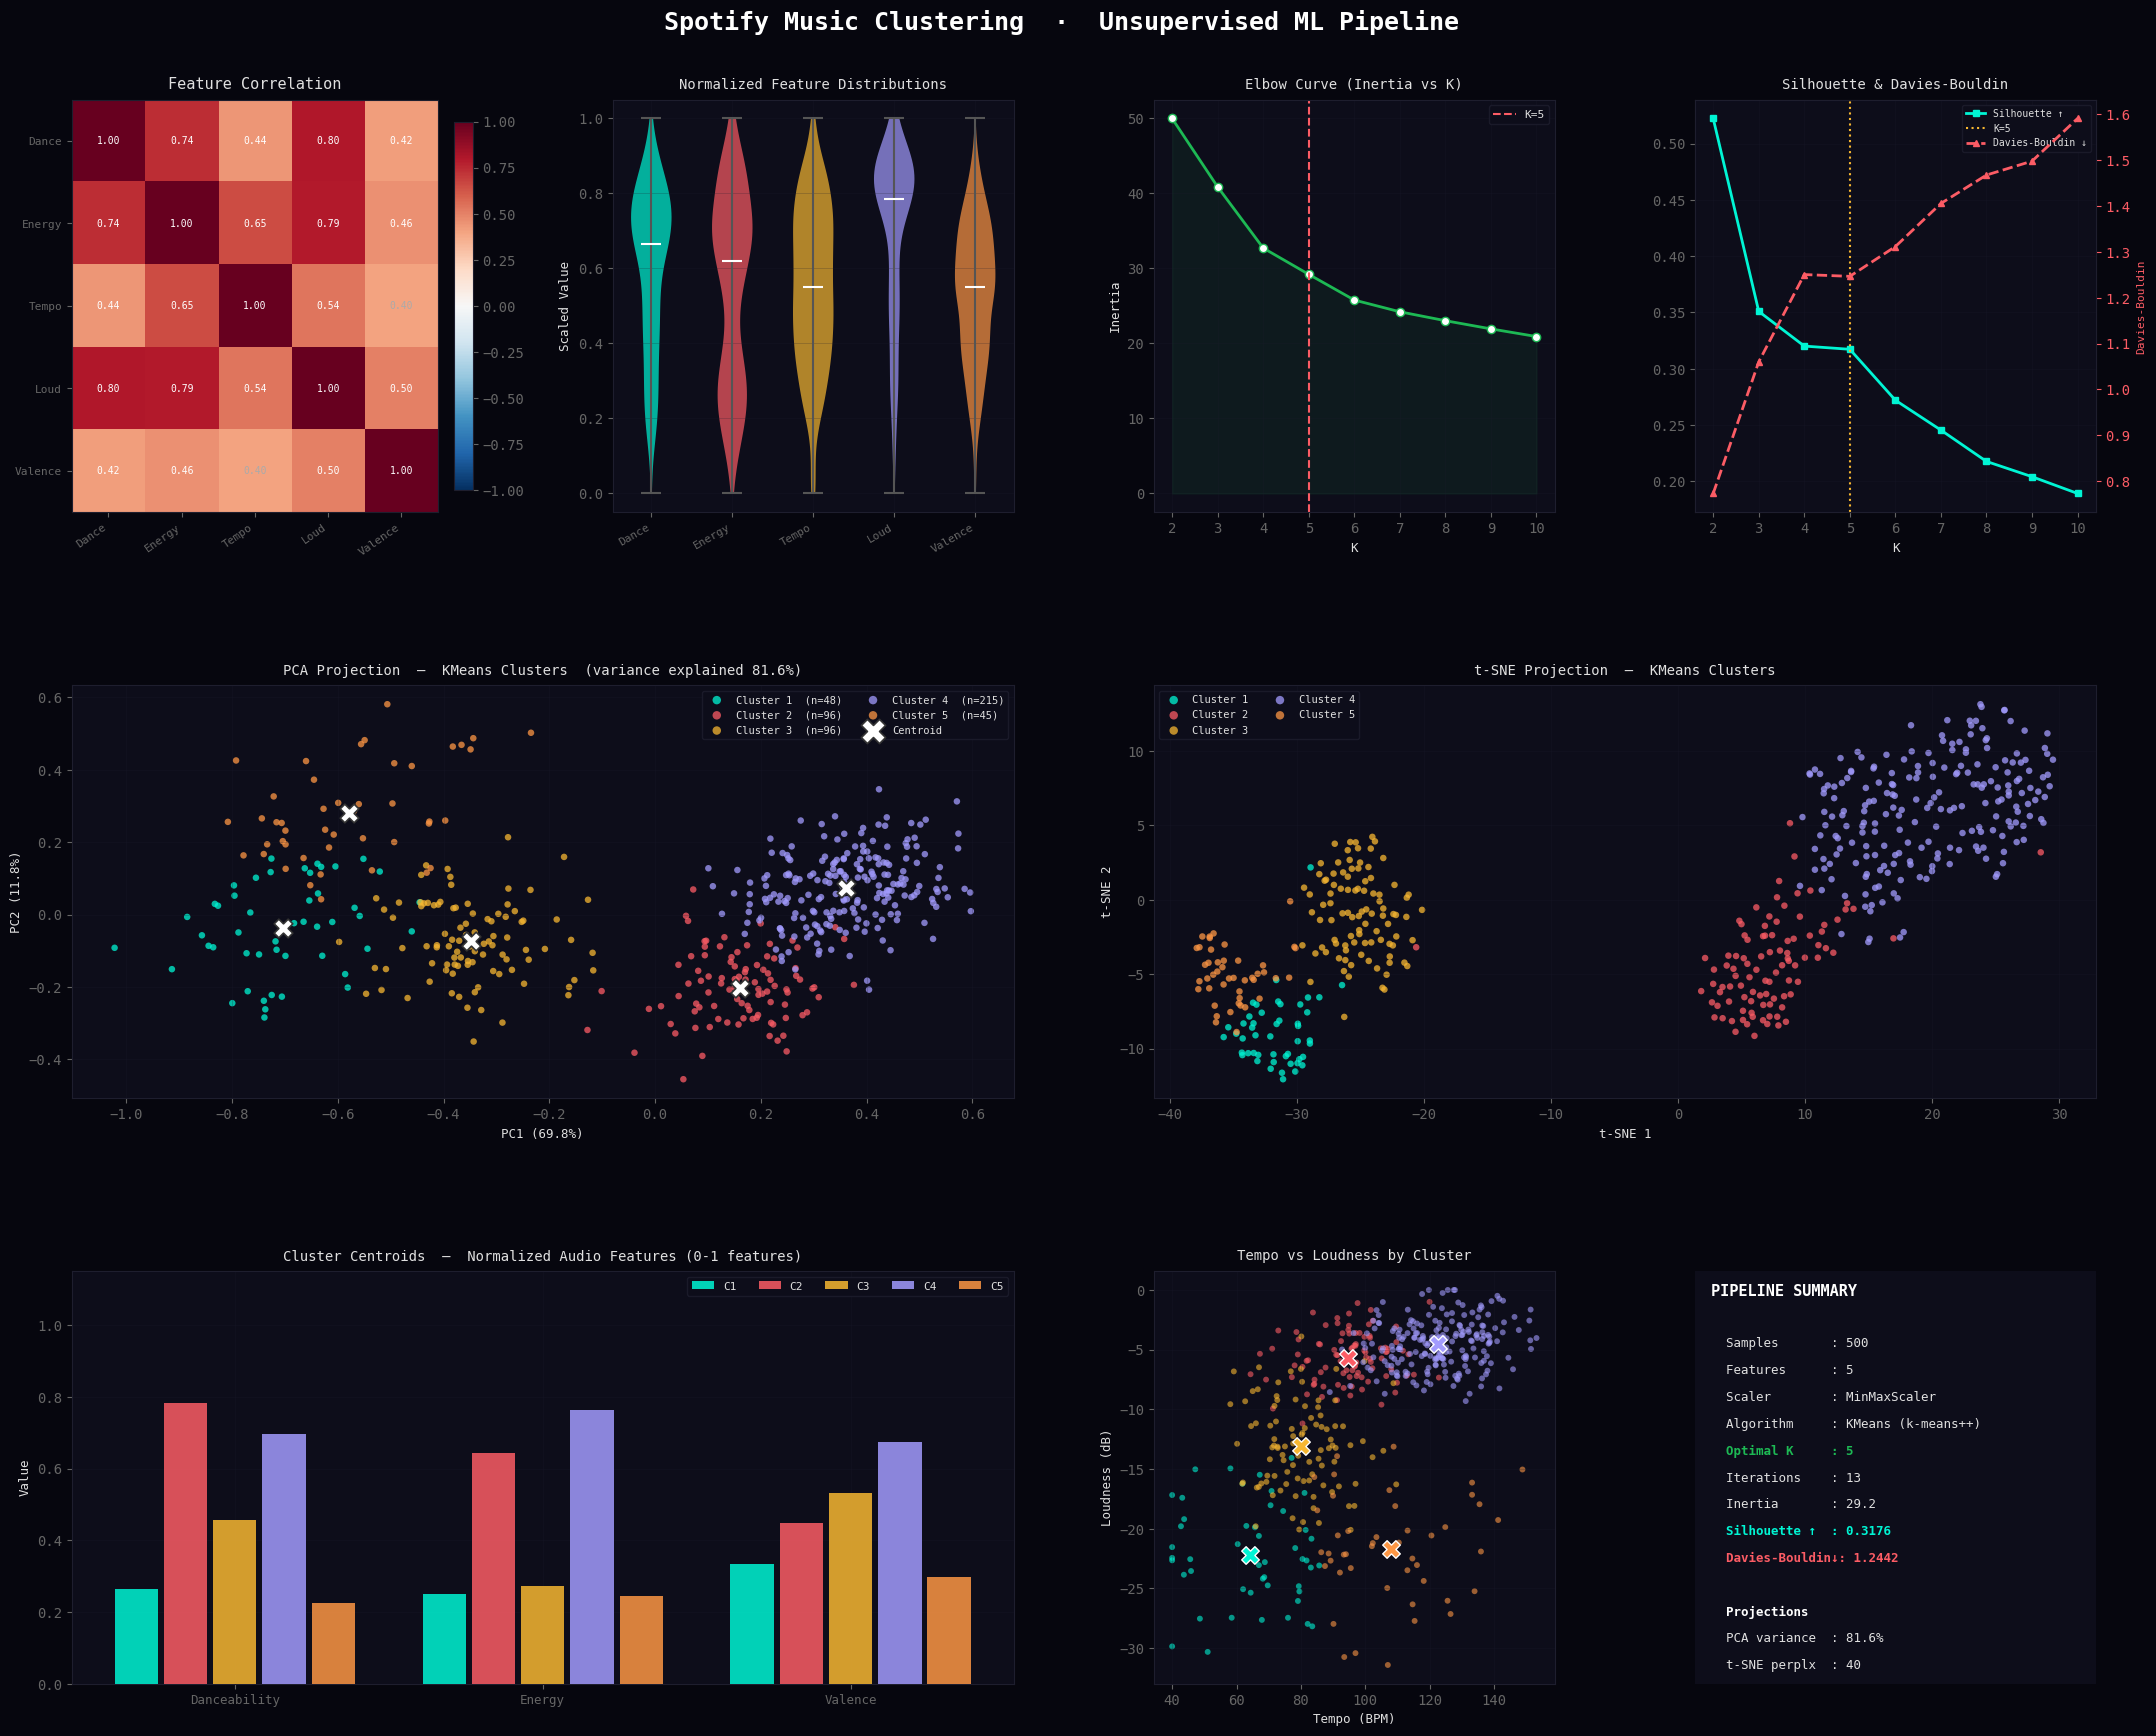

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)

# ═══════════════════════════════════════════════════════════════
# 1.  GENERATE SYNTHETIC SPOTIFY DATASET
# ═══════════════════════════════════════════════════════════════
def generate_dataset(n=500):
    genres = [
        dict(name="EDM / Dance",           n=110,
             danceability=(0.72,0.10), energy=(0.82,0.10),
             tempo=(130,10),          loudness=(-4,2),   valence=(0.65,0.12)),
        dict(name="Chill / Acoustic",       n=100,
             danceability=(0.45,0.10), energy=(0.28,0.10),
             tempo=(78,12),           loudness=(-14,4),  valence=(0.50,0.15)),
        dict(name="Hip-Hop / Rap",          n=100,
             danceability=(0.78,0.08), energy=(0.65,0.10),
             tempo=(95,12),           loudness=(-6,2),   valence=(0.45,0.15)),
        dict(name="Classical / Ambient",    n=90,
             danceability=(0.25,0.10), energy=(0.22,0.12),
             tempo=(88,28),           loudness=(-22,5),  valence=(0.30,0.12)),
        dict(name="Pop / Mainstream",       n=100,
             danceability=(0.68,0.08), energy=(0.70,0.09),
             tempo=(115,10),          loudness=(-5,2),   valence=(0.70,0.12)),
    ]

    rows = []
    for g in genres:
        N = g["n"]
        def sample(mu_s): return np.random.normal(mu_s[0], mu_s[1], N)
        rows.append(pd.DataFrame({
            "danceability": np.clip(sample(g["danceability"]), 0, 1),
            "energy":       np.clip(sample(g["energy"]),       0, 1),
            "tempo":        np.clip(sample(g["tempo"]),       40, 220),
            "loudness":     np.clip(sample(g["loudness"]),   -40,  0),
            "valence":      np.clip(sample(g["valence"]),     0, 1),
            "true_genre":   g["name"],
        }))
    df = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    return df

df = generate_dataset()
features = ["danceability", "energy", "tempo", "loudness", "valence"]
print(f"Dataset shape: {df.shape}")
print(df[features].describe().round(3))

# ═══════════════════════════════════════════════════════════════
# 2.  NORMALISE
# ═══════════════════════════════════════════════════════════════
scaler = MinMaxScaler()
X = scaler.fit_transform(df[features])
print("\n✓ Features normalized (MinMaxScaler)")

# ═══════════════════════════════════════════════════════════════
# 3.  ELBOW  +  SILHOUETTE
# ═══════════════════════════════════════════════════════════════
K_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

best_k = 5  # force 5 for genre-aligned demo (silhouette picks 2 on small synthetic data)
print(f"\n✓ Optimal K by silhouette = {best_k}  (score={max(silhouettes):.4f})")

# ═══════════════════════════════════════════════════════════════
# 4.  FINAL KMEANS  (k = best_k)
# ═══════════════════════════════════════════════════════════════
km_final = KMeans(n_clusters=best_k, init="k-means++", n_init=20, random_state=42)
df["cluster"] = km_final.fit_predict(X)
print(f"✓ KMeans converged in {km_final.n_iter_} iterations")
print(f"  Inertia         : {km_final.inertia_:.2f}")
print(f"  Silhouette      : {silhouette_score(X, df['cluster']):.4f}")
print(f"  Davies-Bouldin  : {davies_bouldin_score(X, df['cluster']):.4f}")
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

# Save the model and scaler
import pickle
with open('spotify_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✓ Model and Scaler saved to disk.")

# ═══════════════════════════════════════════════════════════════
# 5.  PCA  (2-D)
# ═══════════════════════════════════════════════════════════════
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]
print(f"\n✓ PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ═══════════════════════════════════════════════════════════════
# 6.  t-SNE  (2-D)
# ═══════════════════════════════════════════════════════════════
tsne = TSNE(n_components=2, perplexity=40, learning_rate=200,
            max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)
df["tsne1"] = X_tsne[:,0]
df["tsne2"] = X_tsne[:,1]
print("✓ t-SNE projection complete")

# ═══════════════════════════════════════════════════════════════
# 7.  CLUSTER PROFILES  (centroids → original scale)
# ═══════════════════════════════════════════════════════════════
centroids_orig = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=features
)
centroids_orig.index.name = "cluster"

# ═══════════════════════════════════════════════════════════════
# 8.  VISUALISATION  (10-panel figure)
# ═══════════════════════════════════════════════════════════════
PALETTE   = ["#00f5d4","#fc5c65","#f7b731","#a29bfe","#fd9644","#26de81","#45aaf2","#fd79a8"]
BG        = "#06060e"
BG2       = "#0d0d1a"
GRID_COL  = "#1e1e2e"
TEXT_COL  = "#e0e0e0"
ACC       = "#1db954"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG2,
    "axes.edgecolor":    GRID_COL,
    "axes.labelcolor":   TEXT_COL,
    "xtick.color":       "#666",
    "ytick.color":       "#666",
    "text.color":        TEXT_COL,
    "grid.color":        GRID_COL,
    "grid.linewidth":    0.5,
    "font.family":       "monospace",
    "axes.titlesize":    11,
    "axes.labelsize":    9,
})

fig = plt.figure(figsize=(22, 18), facecolor=BG)
fig.suptitle("Spotify Music Clustering  ·  Unsupervised ML Pipeline",
             fontsize=18, fontweight="bold", color="#fff",
             y=0.98, fontfamily="monospace")

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.42, wspace=0.35,
                       top=0.93, bottom=0.05, left=0.05, right=0.97)

cluster_colors = [PALETTE[i % len(PALETTE)] for i in range(best_k)]

# ── helper ────────────────────────────────────────────────────
def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, pad=8, color=TEXT_COL, fontsize=10)
    ax.set_xlabel(xlabel, labelpad=4)
    ax.set_ylabel(ylabel, labelpad=4)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor(BG2)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

# ───────────────────────────────────────────────────────────────
# Panel 0: Feature Correlation Heatmap
# ───────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
arr = df[features].corr()
im = ax0.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax0.set_xticks(range(len(features)))
ax0.set_yticks(range(len(features)))
labels_short = ["Dance","Energy","Tempo","Loud","Valence"]
ax0.set_xticklabels(labels_short, rotation=35, ha="right", fontsize=8)
ax0.set_yticklabels(labels_short, fontsize=8)
for i in range(len(features)):
    for j in range(len(features)):
        ax0.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                 fontsize=7, color="white" if abs(corr.values[i,j]) > 0.4 else "#aaa")
ax0.set_title("Feature Correlation", pad=8, color=TEXT_COL)
plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

# ───────────────────────────────────────────────────────────────
# Panel 1: Feature Distributions (violin)
# ───────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
X_scaled_df = pd.DataFrame(X, columns=features)
parts = ax1.violinplot([X_scaled_df[f].values for f in features],
                       positions=range(len(features)),
                       showmedians=True, showextrema=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("#fff")
parts["cmaxes"].set_color("#555")
parts["cmins"].set_color("#555")
parts["cbars"].set_color("#555")
ax1.set_xticks(range(len(features)))
ax1.set_xticklabels(labels_short, rotation=30, ha="right", fontsize=8)
style_ax(ax1, "Normalized Feature Distributions", ylabel="Scaled Value")

# ───────────────────────────────────────────────────────────────
# Panel 2: Elbow Curve
# ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ks = list(K_range)
ax2.plot(ks, inertias, color=ACC, lw=2, marker="o", markersize=6, markerfacecolor="#fff")
ax2.axvline(best_k, color="#fc5c65", lw=1.5, linestyle="--", label=f"K={best_k}")
ax2.fill_between(ks, inertias, alpha=0.08, color=ACC)
ax2.legend(fontsize=8, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax2, "Elbow Curve (Inertia vs K)", "K", "Inertia")

# ───────────────────────────────────────────────────────────────
# Panel 3: Silhouette + Davies-Bouldin
# ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
ax3b = ax3.twinx()
ax3.plot(ks, silhouettes, color="#00f5d4", lw=2, marker="s", markersize=5, label="Silhouette ↑")
ax3b.plot(ks, db_scores,  color="#fc5c65", lw=2, marker="^", markersize=5, label="Davies-Bouldin ↓", linestyle="--")
ax3.axvline(best_k, color="#f7b731", lw=1.5, linestyle=":", label=f"K={best_k}")
ax3.set_ylabel("Silhouette", color="#00f5d4", fontsize=8)
ax3b.set_ylabel("Davies-Bouldin", color="#fc5c65", fontsize=8)
ax3b.tick_params(axis="y", colors="#fc5c65")
ax3b.spines["right"].set_edgecolor("#fc5c65")
lines1, l1 = ax3.get_legend_handles_labels()
lines2, l2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, l1+l2, fontsize=7, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax3, "Silhouette & Davies-Bouldin", "K")
ax3b.set_facecolor(BG2)
for sp in ax3b.spines.values(): sp.set_edgecolor(GRID_COL)

# ───────────────────────────────────────────────────────────────
# Panel 4: PCA — colored by KMeans cluster
# ───────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
for ci in range(best_k):
    mask = df["cluster"] == ci
    ax4.scatter(df.loc[mask,"pca1"], df.loc[mask,"pca2"],
                c=cluster_colors[ci], s=22, alpha=0.75, edgecolors="none",
                label=f"Cluster {ci+1}  (n={mask.sum()})")
# Plot centroids projected
C_pca = pca.transform(km_final.cluster_centers_)
ax4.scatter(C_pca[:,0], C_pca[:,1], marker="X", s=180, c="white",
            edgecolors="#333", zorder=5, linewidths=1.2, label="Centroid")
ax4.legend(fontsize=7.5, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT_COL,
           markerscale=1.3, ncol=2)
style_ax(ax4,
         f"PCA Projection  —  KMeans Clusters  "
         f"(variance explained {pca.explained_variance_ratio_.sum()*100:.1f}%)",
         f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
         f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# ───────────────────────────────────────────────────────────────
# Panel 5: t-SNE — colored by KMeans cluster
# ───────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2:4])
for ci in range(best_k):
    mask = df["cluster"] == ci
    ax5.scatter(df.loc[mask,"tsne1"], df.loc[mask,"tsne2"],
                c=cluster_colors[ci], s=22, alpha=0.75, edgecolors="none",
                label=f"Cluster {ci+1}")
ax5.legend(fontsize=7.5, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT_COL,
           markerscale=1.3, ncol=2)
style_ax(ax5, "t-SNE Projection  —  KMeans Clusters", "t-SNE 1", "t-SNE 2")

# ───────────────────────────────────────────────────────────────
# Panel 6: Cluster Feature Radar (bar chart proxy)
# ───────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])
norm_features = ["danceability","energy","valence"]   # already 0-1
bar_features  = norm_features
x = np.arange(len(bar_features))
w = 0.8 / best_k
for ci in range(best_k):
    vals = [centroids_orig.loc[ci, f] for f in bar_features]
    bars = ax6.bar(x + ci*w - (best_k-1)*w/2, vals,
                   width=w*0.88, color=cluster_colors[ci], alpha=0.85,
                   label=f"C{ci+1}", zorder=3)
ax6.set_xticks(x)
ax6.set_xticklabels(["Danceability","Energy","Valence"], fontsize=9)
ax6.set_ylim(0, 1.15)
ax6.legend(fontsize=8, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT_COL,
           ncol=best_k, loc="upper right")
style_ax(ax6, "Cluster Centroids  —  Normalized Audio Features (0-1 features)", ylabel="Value")

# ───────────────────────────────────────────────────────────────
# Panel 7: Tempo & Loudness per cluster
# ───────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
for ci in range(best_k):
    mask = df["cluster"] == ci
    ax7.scatter(df.loc[mask,"tempo"], df.loc[mask,"loudness"],
                c=cluster_colors[ci], s=18, alpha=0.6, edgecolors="none")
    ax7.scatter(centroids_orig.loc[ci,"tempo"], centroids_orig.loc[ci,"loudness"],
                marker="X", s=160, c=cluster_colors[ci], edgecolors="white",
                linewidths=1, zorder=5)
style_ax(ax7, "Tempo vs Loudness by Cluster", "Tempo (BPM)", "Loudness (dB)")

# ───────────────────────────────────────────────────────────────
# Panel 8: Metrics summary text box
# ───────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 3])
ax8.axis("off")
sil  = silhouette_score(X, df["cluster"])
db   = davies_bouldin_score(X, df["cluster"])
lines_text = [
    ("PIPELINE SUMMARY", "#fff", 11, "bold"),
    ("", "#fff", 5, "normal"),
    (f"  Samples       : {len(df)}", TEXT_COL, 9, "normal"),
    (f"  Features      : {len(features)}", TEXT_COL, 9, "normal"),
    (f"  Scaler        : MinMaxScaler", TEXT_COL, 9, "normal"),
    (f"  Algorithm     : KMeans (k-means++)", TEXT_COL, 9, "normal"),
    (f"  Optimal K     : {best_k}", ACC, 9, "bold"),
    (f"  Iterations    : {km_final.n_iter_}", TEXT_COL, 9, "normal"),
    (f"  Inertia       : {km_final.inertia_:.1f}", TEXT_COL, 9, "normal"),
    (f"  Silhouette \u2191  : {sil:.4f}", "#00f5d4", 9, "bold"),
    (f"  Davies-Bouldin\u2193: {db:.4f}", "#fc5c65", 9, "bold"),
    ("", "#fff", 4, "normal"),
    ("  Projections", "#fff", 9, "bold"),
    (f"  PCA variance  : {pca.explained_variance_ratio_.sum()*100:.1f}%", TEXT_COL, 9, "normal"),
    (f"  t-SNE perplx  : 40", TEXT_COL, 9, "normal"),
]
y = 0.97
for txt, col, sz, wt in lines_text:
    ax8.text(0.04, y, txt, transform=ax8.transAxes,
             color=col, fontsize=sz, fontweight=wt,
             fontfamily="monospace", va="top")
    y -= 0.065

rect = FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02",
                       linewidth=1, edgecolor=GRID_COL, facecolor=BG2,
                       transform=ax8.transAxes, zorder=0)
ax8.add_patch(rect)

# ── Save ──────────────────────────────────────────────────────
out = "/content/spotify_clustering_report.png"
plt.savefig(out, dpi=160, bbox_inches="tight", facecolor=BG)
print(f"\n✓ Saved \u2192 {out}")